In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("training_data.csv")
df.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


In [3]:
df.isnull().sum()

Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [4]:
"""
Imputing with NaN to get True NaN missing value counts

"""
missing_cols = ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'gender']

column_to_missing = {}
for col in missing_cols:
    if col != 'gender':
        column_to_missing[col] = '?'
    else:
        column_to_missing[col] = 'Unknown/Invalid'

print(column_to_missing)

{'race': '?', 'weight': '?', 'payer_code': '?', 'medical_specialty': '?', 'diag_1': '?', 'diag_2': '?', 'diag_3': '?', 'gender': 'Unknown/Invalid'}


In [5]:
df_1 = df.copy()
for col, miss_val in column_to_missing.items():
    df_1[col] = df_1[col].replace(miss_val, np.nan)
message = "True Missing Counts:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().sum()

True Missing Counts:


Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                         2044
gender                          2
age                             0
weight                      88727
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  36237
medical_specialty           44911
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         19
diag_2                        332
diag_3                       1292
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [6]:
message = "Percentage of Missing Values:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().mean().round(4)*100

Percentage of Missing Values:


Unnamed: 0                   0.00
encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.88
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.04
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.36
diag_3                       1.41
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.27
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride   

In [7]:
df_1_non_numeric = df_1.select_dtypes(exclude='number')
for col in df_1_non_numeric.columns.values:
    print(f"{col}: ", df_1[col].unique(), end='\n\n')

race:  ['Caucasian' 'AfricanAmerican' 'Hispanic' nan 'Other' 'Asian']

gender:  ['Female' 'Male' nan]

age:  ['[60-70)' '[40-50)' '[70-80)' '[80-90)' '[50-60)' '[30-40)' '[20-30)'
 '[90-100)' '[10-20)' '[0-10)']

weight:  [nan '[75-100)' '[100-125)' '[50-75)' '[125-150)' '[25-50)' '[0-25)'
 '[150-175)' '[175-200)' '>200']

payer_code:  ['MC' nan 'BC' 'CM' 'SP' 'HM' 'OG' 'MD' 'UN' 'CP' 'OT' 'PO' 'DM' 'WC' 'SI'
 'CH' 'MP' 'FR']

medical_specialty:  [nan 'Family/GeneralPractice' 'InternalMedicine' 'Cardiology'
 'Surgery-General' 'Surgery-Vascular' 'Urology' 'Emergency/Trauma'
 'Surgery-Neuro' 'Orthopedics-Reconstructive'
 'PhysicalMedicineandRehabilitation' 'Surgery-Cardiovascular/Thoracic'
 'ObstetricsandGynecology' 'Gastroenterology' 'Orthopedics'
 'Surgery-Plastic' 'Podiatry' 'Surgery-Thoracic' 'Nephrology' 'Psychiatry'
 'Radiologist' 'Pulmonology' 'Pediatrics-CriticalCare' 'Psychology'
 'Pediatrics-Endocrinology' 'Neurology' 'Hematology/Oncology' 'Pediatrics'
 'OutreachServices' 'Surg

In [8]:
"""
Diagnosis Groups:

Grouping based on ICD9 Grouping (source: Wikipedia)
"""
diags_ICD9_dict = {
    '001–139': 'infectious and parasitic diseases',
    '140–239': 'neoplasms',
    '240–279': 'endocrine, nutritional and metabolic diseases, and immunity disorders',
    '280–289': 'diseases of the blood and blood-forming organs',
    '290–319': 'mental disorders',
    '320–389': 'diseases of the nervous system and sense organs',
    '390–459': 'diseases of the circulatory system',
    '460–519': 'diseases of the respiratory system',
    '520–579': 'diseases of the digestive system',
    '580–629': 'diseases of the genitourinary system',
    '630–679': 'complications of pregnancy, childbirth, and the puerperium',
    '680–709': 'diseases of the skin and subcutaneous tissue',
    '710–739': 'diseases of the musculoskeletal system and connective tissue',
    '740–759': 'congenital anomalies',
    '760–779': 'certain conditions originating in the perinatal period',
    '780–799': 'symptoms, signs, and ill-defined conditions',
    '800–999': 'injury and poisoning',
    'E & V codes': 'external causes of injury and supplemental classification',
}

def categorize_diag(code: str) -> str:
    code_float = float(code)
    code_int = int(code_float)
    if code_int >= 800:
        return '800–999'
    elif code_int >= 780:
        return '780–799'
    elif code_int >= 760:
        return '760–779'
    elif code_int >= 740:
        return '740–759'
    elif code_int >= 710:
        return '710–739'
    elif code_int >= 680:
        return '680–709'
    elif code_int >= 630:
        return '630–679'
    elif code_int >= 580:
        return '580–629'
    elif code_int >= 520:
        return '520–579'
    elif code_int >= 460:
        return '460–519'
    elif code_int >= 390:
        return '390–459'
    elif code_int >= 320:
        return '320–389'
    elif code_int >= 290:
        return '290–319'
    elif code_int >= 280:
        return '280–289'
    elif code_int >= 240:
        return '240–279'
    elif code_int >= 140:
        return '140–239'
    else:
        return '001–139'

def convert_EV_code(code: str) -> str:
    return 'E & V codes'


"""
Medical Specialty Groups:

Grouping based on Google Gemini output
"""

specialty_mapping = {
    'PrimaryCare': [
        'Family/GeneralPractice', 'InternalMedicine', 'Hospitalist', 
        'Osteopath', 'Resident'
    ],
    'Surgery': [
        'Surgery-General', 'Surgery-Vascular', 'Urology', 'Surgery-Neuro', 
        'Orthopedics-Reconstructive', 'Surgery-Cardiovascular/Thoracic', 
        'Orthopedics', 'Surgery-Plastic', 'Podiatry', 'Surgery-Thoracic', 
        'Surgery-Colon&Rectal', 'Otolaryngology', 'Surgery-Cardiovascular', 
        'Surgeon', 'Proctology', 'Surgery-Maxillofacial', 'SurgicalSpecialty', 
        'Dentistry', 'Ophthalmology', 'Surgery-PlasticwithinHeadandNeck'
    ],
    'InternalMedicine_Subspecialty': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Pulmonology', 
        'Neurology', 'Hematology/Oncology', 'Endocrinology-Metabolism', 
        'Hematology', 'Oncology', 'Endocrinology', 'InfectiousDiseases', 
        'Rheumatology', 'AllergyandImmunology', 'Neurophysiology', 'Dermatology'
    ],
    'Emergency_CriticalCare': [
        'Emergency/Trauma'
    ],
    'Maternal_Pediatric': [
        'ObstetricsandGynecology', 'Pediatrics-CriticalCare', 'Pediatrics-Endocrinology', 
        'Pediatrics', 'Gynecology', 'Pediatrics-Pulmonology', 'Pediatrics-Neurology', 
        'Obsterics&Gynecology-GynecologicOnco', 'Pediatrics-AllergyandImmunology', 
        'Cardiology-Pediatric', 'Anesthesiology-Pediatric', 'Obstetrics', 
        'Surgery-Pediatric', 'Perinatology', 'Pediatrics-EmergencyMedicine', 
        'Pediatrics-Hematology-Oncology', 'Psychiatry-Child/Adolescent', 
        'Pediatrics-InfectiousDiseases'
    ],
    'Psych_Rehab_Support': [
        'PhysicalMedicineandRehabilitation', 'Psychiatry', 'Psychology', 
        'Anesthesiology', 'Speech', 'SportsMedicine'
    ],
    'Diagnostics_Other': [
        'Radiologist', 'Radiology', 'Pathology', 'OutreachServices', 'DCPTEAM'
    ],
    'Missing': [
        'PhysicianNotFound'
    ]
}

def map_specialty_to_group(specialty):
    if pd.isna(specialty):
        return specialty
    for key, value in specialty_mapping.items():
        if specialty in value:
            return key
    return 'Other'

---
## Starting Feature Transformations & Imputation

In [9]:
"""
Grouping Transformations (4 total)

2 types: diagnosis and medical specialty
"""

"""
Categorizing diagnoses codes into diagnosis groups => reduces features.

Applies to: `diag_1`, `diag_2`, & `diag_3`
"""
df_2 = df_1.copy()
for i in range(1,4):

    mask = df_2[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_2[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan
    
    df_2.loc[~combined_mask, f'diag_{i}'] = df_2.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_2.loc[mask, f'diag_{i}'] = df_2.loc[mask, f'diag_{i}'].apply(convert_EV_code)
    print(f"diag_{i}: ", df_2[f'diag_{i}'].unique(), end='\n\n')

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_2['medical_specialty'] = df_2['medical_specialty'].apply(map_specialty_to_group)
df_2['medical_specialty'].unique()

diag_1:  ['460–519' '390–459' '520–579' '710–739' '800–999' '780–799' '290–319'
 '140–239' '240–279' '580–629' '001–139' 'E & V codes' '630–679' '680–709'
 '280–289' '320–389' nan '740–759']

diag_2:  ['390–459' '240–279' '280–289' '580–629' 'E & V codes' '780–799' '460–519'
 '320–389' '520–579' '290–319' '680–709' '001–139' '800–999' '710–739'
 '140–239' '630–679' nan '740–759']

diag_3:  ['520–579' '290–319' '580–629' '680–709' '390–459' '240–279' 'E & V codes'
 '001–139' '460–519' '320–389' '280–289' '780–799' '630–679' '800–999'
 '710–739' nan '740–759' '140–239']



array([nan, 'PrimaryCare', 'InternalMedicine_Subspecialty', 'Surgery',
       'Emergency_CriticalCare', 'Psych_Rehab_Support',
       'Maternal_Pediatric', 'Diagnostics_Other', 'Missing'], dtype=object)

In [10]:
"""
Feature Drops:

Reasoning: 
- feature has missing 90+% of values (weight)
- feature only consists of 1 unique value
"""
df_3 = df_2.copy()
df_3.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)
print("Shape BEFORE drops: ", df_2.shape)
print("Shape AFTER drops: ", df_3.shape)

Shape BEFORE drops:  (91589, 51)
Shape AFTER drops:  (91589, 48)


In [11]:
"""
Mode Imputation
"""
df_4 = df_3.copy()
mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    print(f"Mode:\t\t", mode)
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    print(name, end=' ')
    df_4[name] = mode_impute(df_4[name])

race Mode:		 Caucasian
payer_code Mode:		 MC
medical_specialty Mode:		 PrimaryCare
gender Mode:		 Female
diag_1 Mode:		 390–459
diag_2 Mode:		 390–459
diag_3 Mode:		 390–459


In [12]:
message = "Before Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_3[mode_impute_col_names].isnull().sum()

Before Mode Impute:


race                  2044
payer_code           36237
medical_specialty    44911
gender                   2
diag_1                  19
diag_2                 332
diag_3                1292
dtype: int64

In [13]:
message = "After Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_4[mode_impute_col_names].isnull().sum()

After Mode Impute:


race                 0
payer_code           0
medical_specialty    0
gender               0
diag_1               0
diag_2               0
diag_3               0
dtype: int64

In [14]:
"""
NaN Replacement:

Treating Unknown as a possible valid value.

Applies to: 'max_glu_serum', 'A1Cresult'

Based on potential significance of these values missing.
"""
df_5 = df_4.copy()
col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_5[name] = df_5[name].replace(np.nan, 'Unknown')

In [15]:
message = "After ALL Transformations and Imputes:"
print(message, '\n', '='*len(message), sep='')
df_5.isna().sum()

After ALL Transformations and Imputes:


Unnamed: 0                  0
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

## Done with Imputations and Transformations
---
## Starting Encoding
### **NOTE**: Use `df_5` from this point onwards.

In [16]:
df_5_non_numeric = df_5.select_dtypes(exclude='number')

categorical_columns = list(df_5_non_numeric.columns.values)

non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8]
ordinal_cols = categorical_columns[1:3] + categorical_columns[8:]

print("categorical_columns: ", categorical_columns, end='\n\n')
print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
print("Ordinal: ", ordinal_cols)

categorical_columns:  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Non Ordinal:  ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']

Ordinal:  ['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metf

In [17]:
"""
Define Orderings for every ordinal column
"""

quad_med = ['Down', 'No', 'Steady', 'Up']
binary_med = ['No', 'Steady']

mapping = {
    # Custom/Unique orderings
    'gender': ['Male', 'Female'],
    'age': ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'],
    'weight': ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '>200'],
    'max_glu_serum': ['Unknown', 'Norm', '>200', '>300'],
    'A1Cresult': ['Unknown', 'Norm', '>7', '>8'],
    'change': ['No', 'Ch'],
    'diabetesMed': ['No', 'Yes'],
    'readmitted': ['NO', '>30', '<30'],
    
    # 3-level medication (Unique)
    'tolazamide': ['No', 'Steady', 'Up'],
    
    # 4-level medications (Repeated)
    'metformin': quad_med,
    'repaglinide': quad_med,
    'nateglinide': quad_med,
    'chlorpropamide': quad_med,
    'glimepiride': quad_med,
    'glipizide': quad_med,
    'glyburide': quad_med,
    'pioglitazone': quad_med,
    'rosiglitazone': quad_med,
    'acarbose': quad_med,
    'miglitol': quad_med,
    'insulin': quad_med,
    'glyburide-metformin': quad_med,
    
    # 2-level medications (Repeated)
    'acetohexamide': binary_med,
    'tolbutamide': binary_med,
    'troglitazone': binary_med,
    'glipizide-metformin': binary_med,
    'glimepiride-pioglitazone': binary_med,
    'metformin-rosiglitazone': binary_med,
    'metformin-pioglitazone': binary_med
}

In [18]:
"""
Performing Encodings:

First starting with Ordinal Encoding

Second doing the Non-ordinal (OneHot) Encoding
"""

df_6 = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_6[col] = ord_enc.fit_transform(df_6[[col]])

# Non-Ordinal, One-Hot Encoding
df_6 = pd.get_dummies(df_6, columns=non_ordinal_cols, drop_first=True)

In [19]:
df_6.head()

,Unnamed: 0,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes
0,83148,259912530,88114716,1.0,6.0,1,6,7,1,34,0,10,6,0,0,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,8067,37094196,604017,1.0,6.0,1,1,7,2,39,0,11,0,0,0,4,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,19623,69819834,3401055,1.0,4.0,1,6,7,5,63,1,11,1,0,11,5,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,77236,234245010,71780013,0.0,7.0,2,6,1,2,39,0,22,3,0,2,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False

In [20]:
df_6.shape

(91589, 117)

## End of Encodings
---
### **NOTE**: Please use `df_6` from here on out.
---
## Start of EDA - Exploratory Data Analysis

<Axes: >

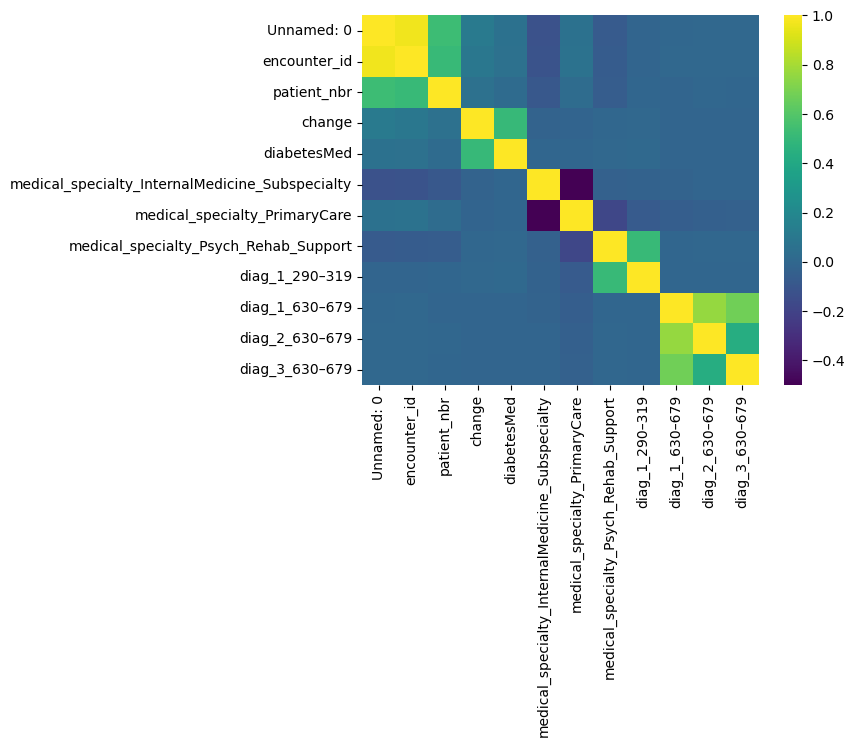

In [43]:
min_thresh = 0.5
corr_matrix = df_6.corr(numeric_only=True)
high_corr_features = corr_matrix.index[(abs(corr_matrix) >= min_thresh).sum() > 1]
high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
sns.heatmap(high_corr_matrix, cmap='viridis')

In [77]:
"""
Skew Analysis
"""
# Skewness Thresholds
upper_bound, lower_bound = 0.5, -0.5

all_cols = df_6.columns
encoded_cols = set(df_6.filter(regex=rf"^({'|'.join(categorical_columns)})_").columns)
non_encoded_cols = [c for c in all_cols if c not in encoded_cols]

non_encoded_skews = []
for col in sorted(non_encoded_cols):
    if pd.api.types.is_numeric_dtype(df_6[col]):
        skewness = df_6[col].skew()
        if skewness > upper_bound or skewness < lower_bound:
            non_encoded_skews.append((col,skewness))

encoded_skews = []
for category in categorical_columns:
    cols = df_6.filter(regex=rf'^{category}_').columns
    if not cols.empty:
        series = df_6[cols].values.argmax(axis=1)
        group_skew = pd.Series(series).skew()
        if group_skew > upper_bound or group_skew < lower_bound:
            encoded_skews.append((category, group_skew))

non_encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))
encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))

message = "Skewed Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in non_encoded_skews:
    print(f"{col:30} Skew: {skew:.4f}")

message = "\nSkewed Non-Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in encoded_skews:
    print(f"Grouped {col:22} Skew: {skew:.4f}")

Skewed Ordinal Columns:
acetohexamide                  Skew: 302.6367
glimepiride-pioglitazone       Skew: 302.6367
metformin-pioglitazone         Skew: 302.6367
metformin-rosiglitazone        Skew: 302.6367
troglitazone                   Skew: 302.6367
glipizide-metformin            Skew: 95.6880
tolbutamide                    Skew: 67.6506
tolazamide                     Skew: 54.2353
miglitol                       Skew: 46.6691
chlorpropamide                 Skew: 36.8230
number_emergency               Skew: 23.8095
acarbose                       Skew: 18.6509
nateglinide                    Skew: 12.4290
glyburide-metformin            Skew: 12.0035
number_outpatient              Skew: 8.9312
repaglinide                    Skew: 8.4440
max_glu_serum                  Skew: 5.2494
glimepiride                    Skew: 4.3353
rosiglitazone                  Skew: 3.7772
number_inpatient               Skew: 3.6163
pioglitazone                   Skew: 3.4828
glyburide                      Sk

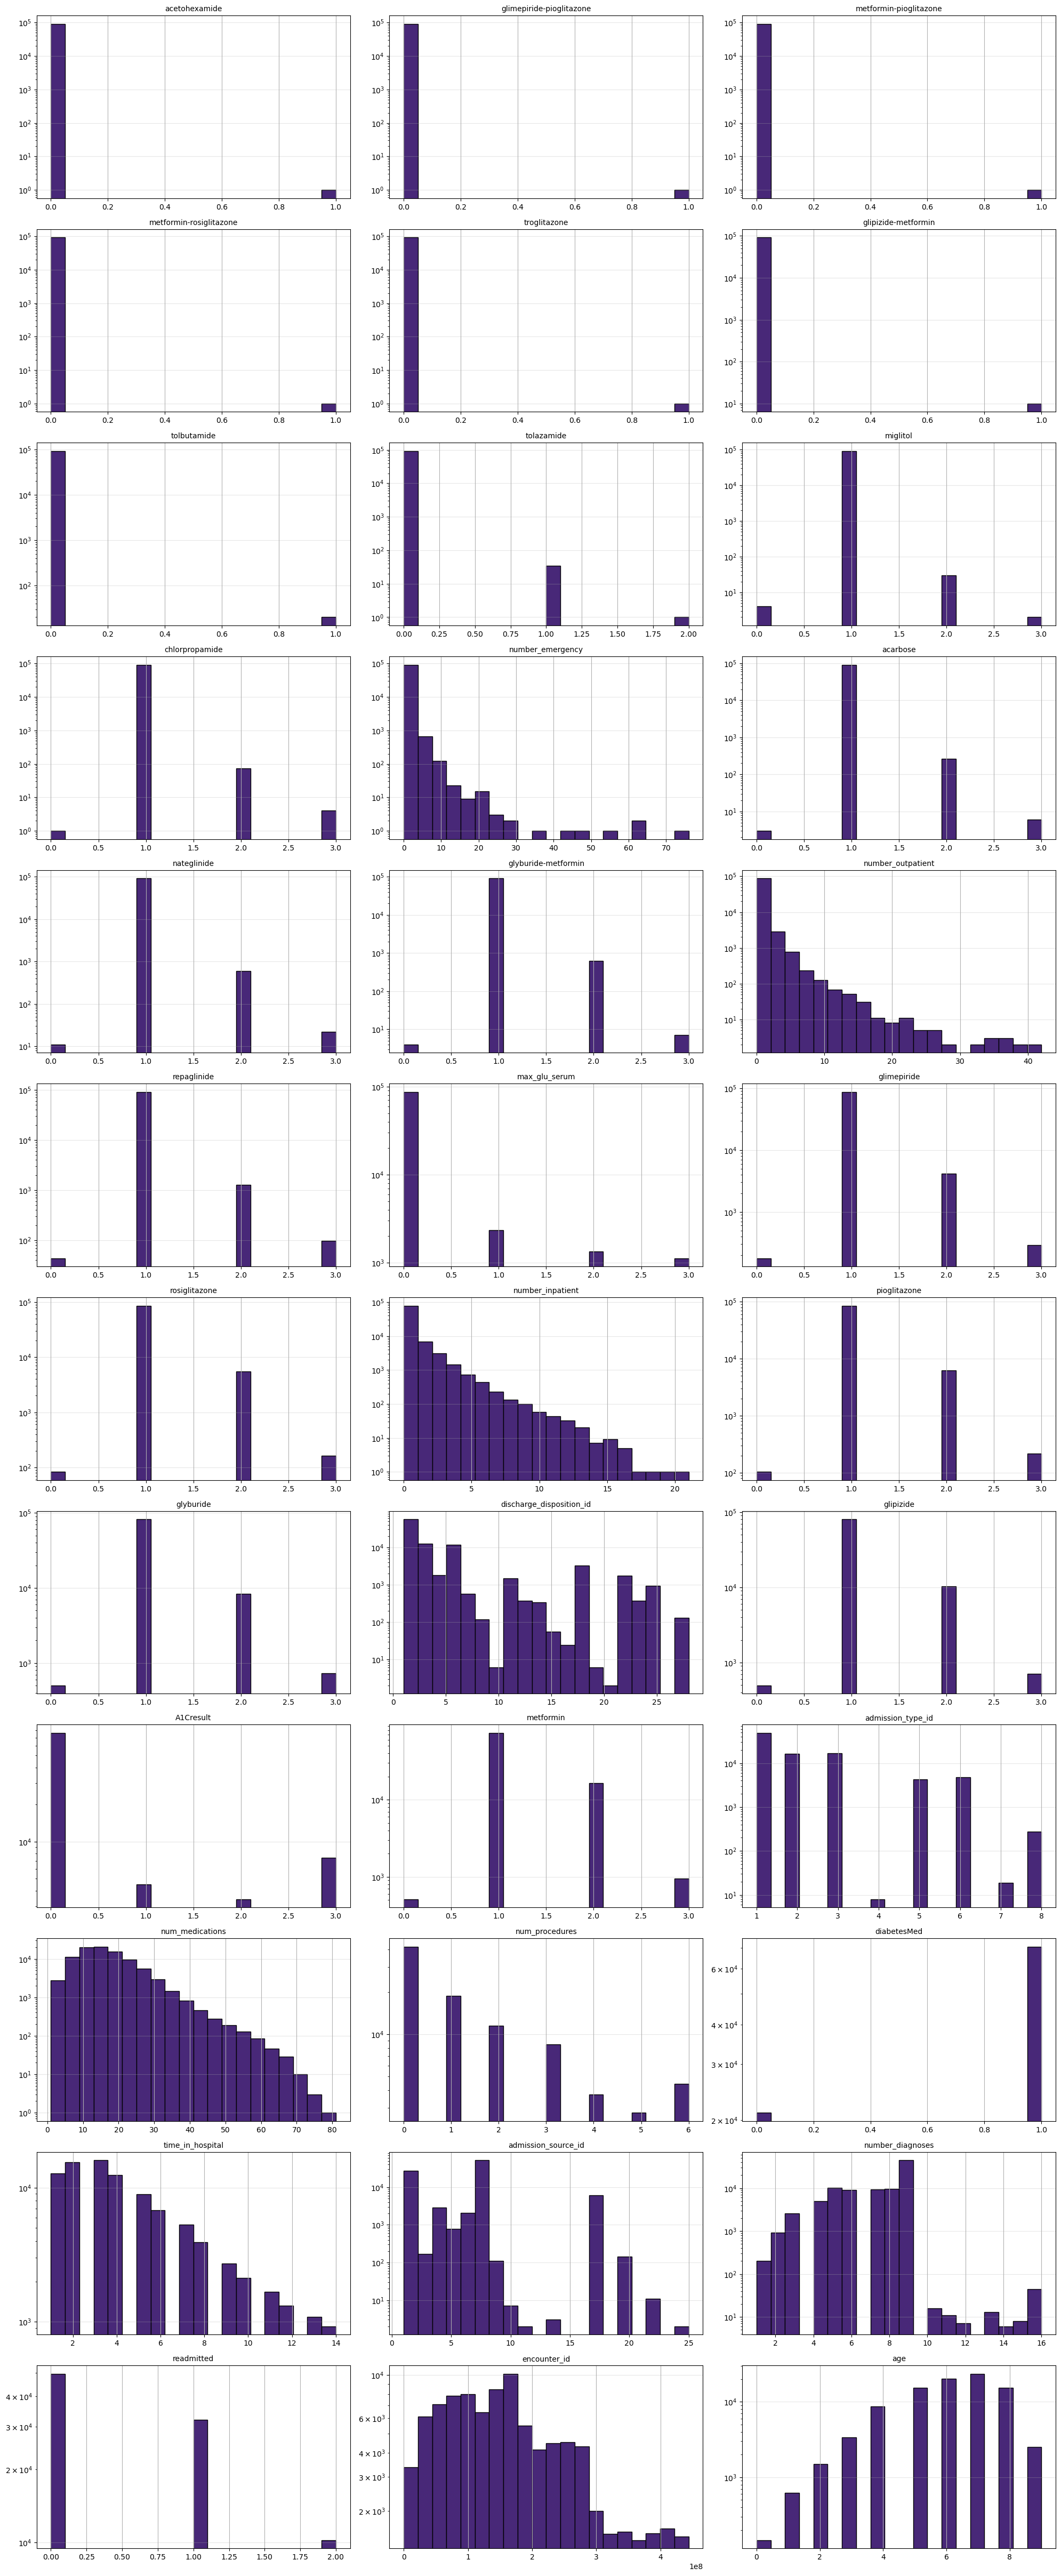

In [93]:
"""
Visualize Skew in Data via Histogram
"""
num_features = len(non_encoded_skews)
num_cols = 3
num_rows = num_features // num_cols + 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten()

for i, (col, skew) in enumerate(non_encoded_skews):
    ax = axes[i]
    
    df_6[col].hist(ax=ax, color='#482878', edgecolor='black', bins=20)
    
    ax.set_yscale('log')
    
    ax.set_title(f"{col}", fontsize=10)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [90]:
"""
Outlier Analysis
"""

'\nOutlier Analysis\n'

In [91]:
"""
Log Transforms => Logistic Classifer
"""

'\nLog Transforms => Logistic Classifer\n'

In [92]:
"""
Multicollinearity Test
"""

'\nMulticollinearity Test\n'

## End of Exploratory Data Analysis
---
## Start of Model Building